# STEP 0:
## SETUP AND SECTOR FILTER

In [40]:
# 1. IMPORTING LIBRARIES AND LOADING THE DATASET

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations and handling missing/infinite values.
import numpy as np

# Import the dataset with the original data to start the cleaning operation
df_raw = pd.read_csv('symbol_info_3-25.csv')

# Show the dataset shape: rows and columns.
print("Dataset shape:", df_raw.shape)

# Preview the first rows.
df_raw.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,...,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,...,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,...,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,...,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,...,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [41]:
# 2. DATA INSPENCTION
# used to understand data

summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
})

summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


In [42]:
# 3. DATA CLEANING

# - is_etf == 0 and is_fund == 0: We exclude etf and fund because including them would lead to double or incorrect counting of market capitalization.
# - is_actively_trading == 1: We consider only active companies, excluding those that have been suspended or delisted.
# - market_cap > 0: We esclude negative value to avoid missing data
# - total_revenue > 0: We esclude companies without revenue
df_clean = df_raw[
    (df_raw['is_etf'] == 0) & 
    (df_raw['is_fund'] == 0) & 
    (df_raw['is_actively_trading'] == 1) & 
    (df_raw['market_cap'] > 0) &
    (df_raw['total_revenue'] > 0)
].copy()


# selection of the sector: UTILITIES (STUDENT ID: 99220)
my_sector = 'Utilities'
df_sector = df_clean[df_clean['sector'] == my_sector].copy()


# 4. Optimization of numerical scales
# We divide by 1 billion (1e9) to make the numbers easier to read in graphs.
df_sector['market_cap_b'] = df_sector['market_cap'] / 1e9
df_sector['revenue_b'] = df_sector['total_revenue'] / 1e9
df_sector['enterprise_value_b'] = df_sector['enterprise_value'] / 1e9
df_sector['net_income_b'] = df_sector['net_income'] / 1e9
df_sector['free_cashflow_b'] = df_sector['free_cashflow'] / 1e9

# Verify the result
print(f"Original dataset: {len(df_raw)} raw")
print(f"Sector '{my_sector}' after the cleaning: {len(df_sector)} companies")


# Visualize first row
df_sector[['symbol', 'company_name', 'industry', 'market_cap_b', 'revenue_b', 'enterprise_value_b', 'net_income_b', 'free_cashflow_b']].head()

Original dataset: 1000 raw
Sector 'Utilities' after the cleaning: 42 companies


,symbol,company_name,industry,market_cap_b,revenue_b,enterprise_value_b,net_income_b,free_cashflow_b
73,NEE,"NextEra Energy, Inc.",Utilities - Regulated Electric,146.357273,24.753000,238.635024,6.946,1.844674e+10
117,SO,Southern Company (The),Utilities - Regulated Electric,98.679357,26.724000,166.683247,4.401,7.223750e-01
123,DUK,Duke Energy Corporation (Holdin,Utilities - Regulated Electric,93.366895,29.934000,179.702514,4.392,1.844674e+10
124,GEV,GE Vernova Inc.,Utilities - Renewable,92.931711,34.935001,86.017982,1.552,3.543625e+00
172,CEG,Constellation Energy Corporatio,Utilities - Renewable,69.705212,23.567999,74.997203,3.749,4.225375e+00


# STEP 1:
## MARKET CAPITALIZATION DISTRIBUTION

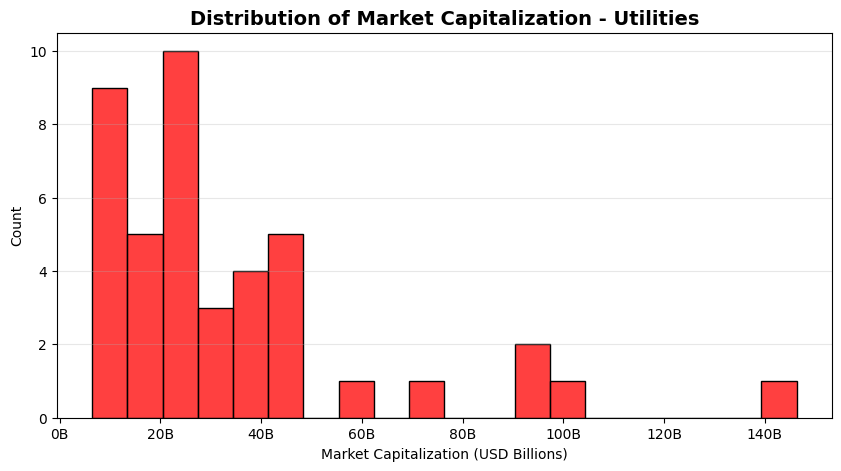

In [43]:
# 4.  MARKET CAPITALIZATION DISTRIBUTION OF UTILITIES (Basic Histogram)

# Matplotlib serves as the primary engine to build the structure of our charts and manage the graphical layout.
import matplotlib.pyplot as plt

# Seaborn builds upon Matplotlib to create highly readable and aesthetically pleasing statistical graphics.
import seaborn as sns

# Is applied to customize axis labels, converting massive financial figures into clean, readable formats (e.g., billions).
from matplotlib.ticker import FuncFormatter



# Creation of the figure
plt.figure(figsize=(10, 5))

sns.histplot(df_sector['market_cap_b'], bins=20, color='red', edgecolor='black')

# Formatting axes and title
plt.title(f'Distribution of Market Capitalization - {my_sector}', fontsize=14, fontweight='bold')
plt.xlabel('Market Capitalization (USD Billions)')
plt.ylabel('Count')


def billions_formatter(x, pos):
    return f"{x:.0f}B"

# This is used to change the appearance of the numbers on the horizontal axis, using the billions_formatter function created earlier.
plt.gca().xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# A subtle horizontal grid (alpha=0.3) is applied to the Y-axis. 
# This reduces 'chart junk' while still providing a visual guide to accurately read the frequency of companies in each bin, keeping the focus entirely on the data.
plt.grid(axis='y', alpha=0.3)

plt.show()


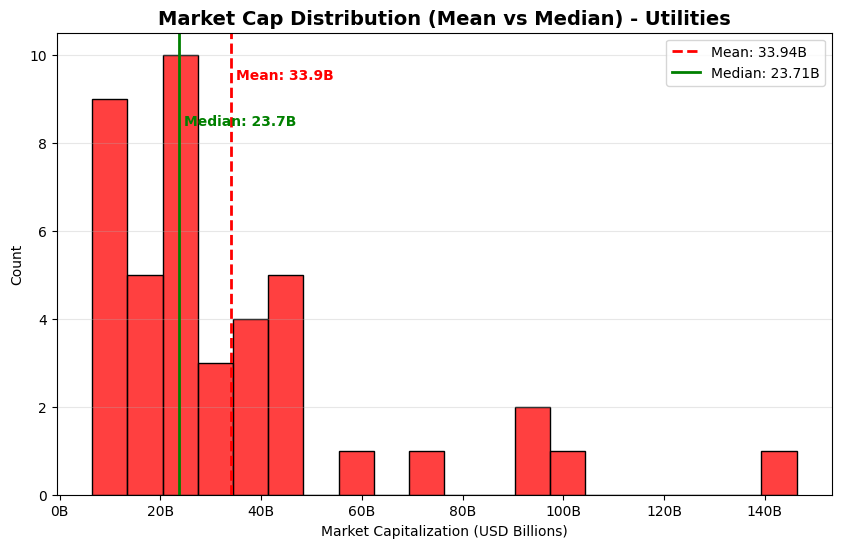

In [44]:
# 5. MARKET CAP DISTRIBUTION OF UTILITIES WITH STATISTICAL ANNOTATIONS

# We calculate Mean and Median
mean_val = df_sector['market_cap_b'].mean()
median_val = df_sector['market_cap_b'].median()

# Creation of the figurae
plt.figure(figsize=(10, 6))

# Rewrite the histogram we had before
sns.histplot(df_sector['market_cap_b'], bins=20, color='red', edgecolor='black')

# Add vertical line of Mean and Median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}B')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}B')


# We calculate the max height (y_max)
y_max = plt.ylim()[1]
plt.text(mean_val + 1, y_max * 0.9, f'Mean: {mean_val:.1f}B', color='red', fontweight='bold')
plt.text(median_val + 1, y_max * 0.8, f'Median: {median_val:.1f}B', color='green', fontweight='bold')

# Final formattation
plt.title(f'Market Cap Distribution (Mean vs Median) - {my_sector}', fontsize=14, fontweight='bold')
plt.xlabel('Market Capitalization (USD Billions)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_formatter(FuncFormatter(billions_formatter))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# STEP 2: 
## OUTLIER DETECTION

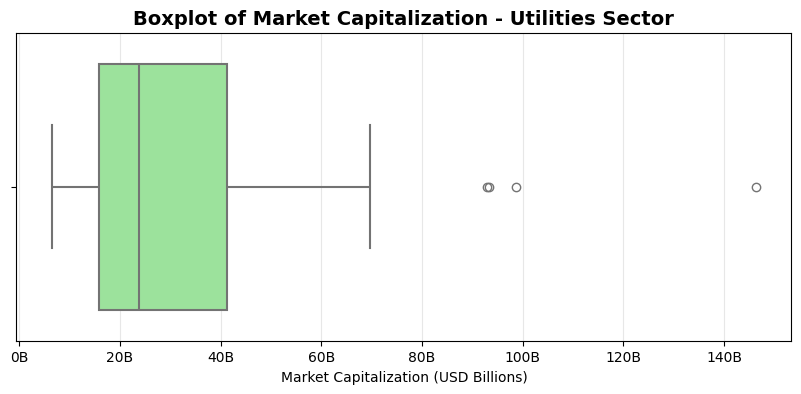

Original dataset size: 42 companies
Dataset successfully cleaned (Market Cap & Revenue). Total companies remaining: 37


In [45]:
# 6. SHOWING BOXPLOT WITH OUTLIERS 

# Figure Creation
plt.figure(figsize=(10, 4))

# Boxplot Creation
# Use " x= " to create an horizontal box plot, for better readability
sns.boxplot(x=df_sector['market_cap_b'], color='lightgreen', fliersize=6, linewidth=1.5)

# Formatting
plt.title(f'Boxplot of Market Capitalization - {my_sector} Sector', fontsize=14, fontweight='bold')
plt.xlabel('Market Capitalization (USD Billions)')

plt.gca().xaxis.set_major_formatter(FuncFormatter(billions_formatter))
plt.grid(axis='x', alpha=0.3)

plt.show()


# 7. OUTLIER REMOVAL (IQR METHOD) 

# We calculate IQR for Market Cap
Q1_mc = df_sector['market_cap_b'].quantile(0.25)
Q3_mc = df_sector['market_cap_b'].quantile(0.75)
IQR_mc = Q3_mc - Q1_mc
upper_mc = Q3_mc + 1.5 * IQR_mc

# We calculate IQR for Total Revenue
Q1_rev = df_sector['revenue_b'].quantile(0.25)
Q3_rev = df_sector['revenue_b'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev
upper_rev = Q3_rev + 1.5 * IQR_rev

# Filter the dataset removing the "giants" from both the columns
df_sector_clean = df_sector[(df_sector['market_cap_b'] <= upper_mc) & 
                            (df_sector['revenue_b'] <= upper_rev)].copy()

print(f"Original dataset size: {len(df_sector)} companies")
print(f"Dataset successfully cleaned (Market Cap & Revenue). Total companies remaining: {len(df_sector_clean)}")

# Justification: The initial analysis shows significant right-tail skewness caused by extreme values in Market Cap and Revenue. 
# Removing these statistical outliers through the IQR method ensures the dataset is normalized. 
# This reduces noise and allows the resulting data to accurately reflect the distribution and variance of the sector's core population.

# STEP 3:
## INDUSTRY COMPARISON: FOUR METRICS

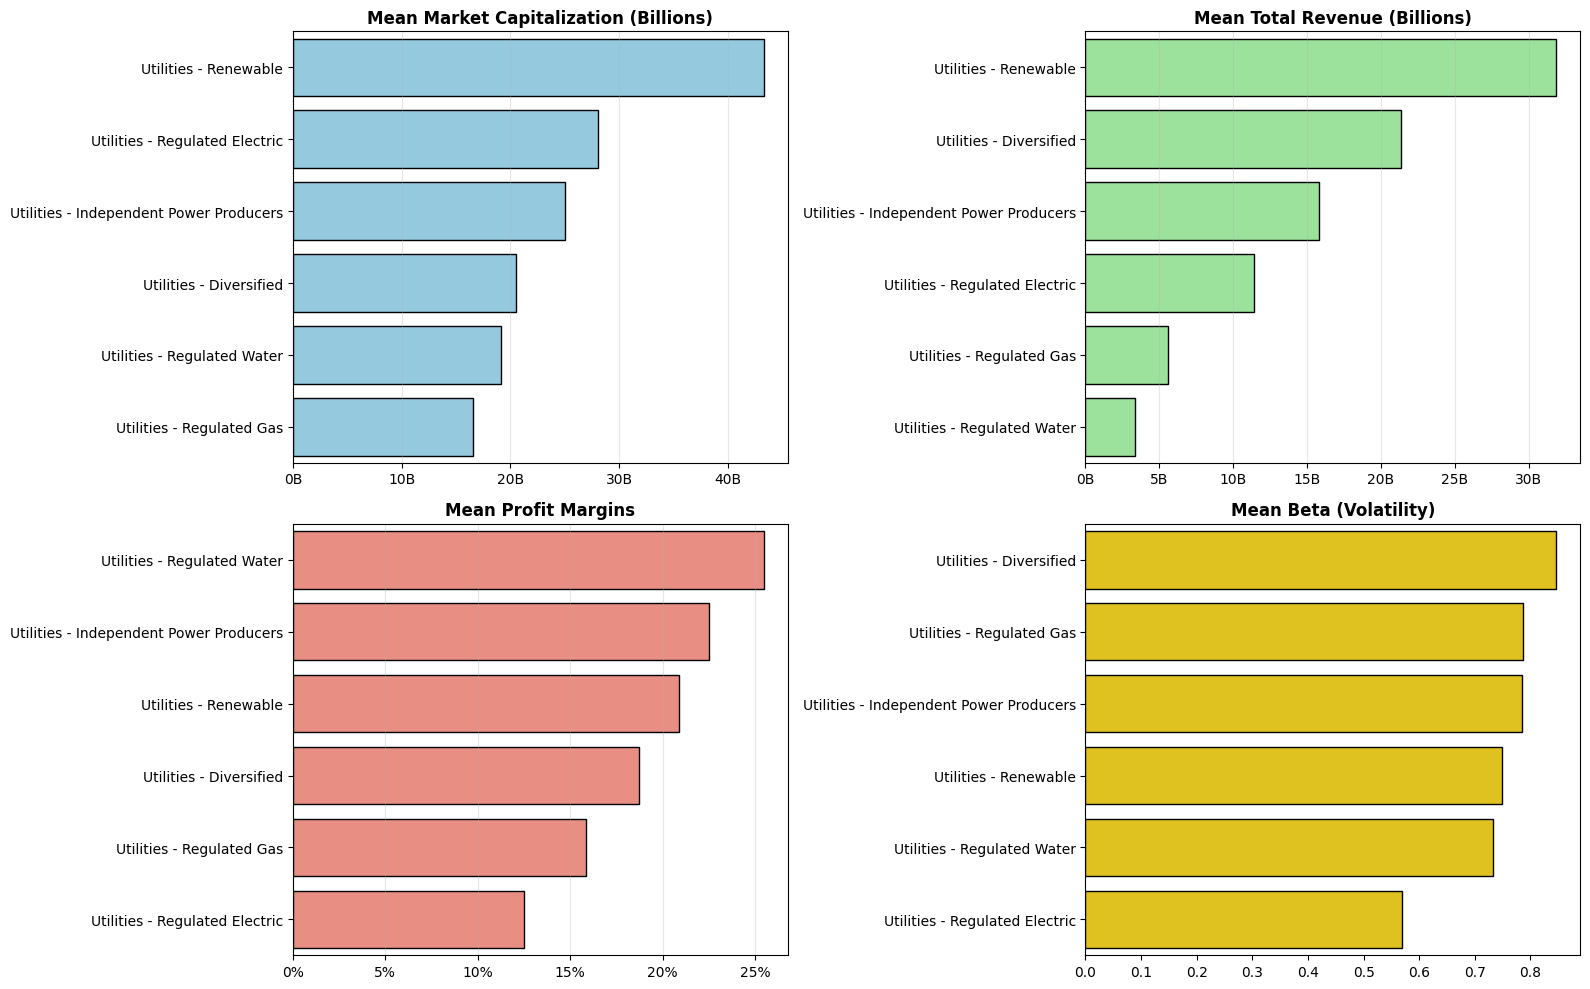

In [46]:

# 8. DECONSTRUCTING THE SECTOR BY KEY FINANCIAL METRICS

# In this step, we move from a macro view of the overall sector to a more granular analysis at the industry level.

# Data aggregation
# We group by 'industry' and calculate the mean for our four target metrics
industry_means = df_sector_clean.groupby('industry')[
    ['market_cap_b', 'revenue_b', 'profit_margins', 'beta']
].mean().reset_index()

# Define a custom formatter to display profit margins as percentages
def pct_formatter(x, pos):
    return f"{x*100:.0f}%"

# FIGURE SETUP
# We create a 2x2 grid for our subplots.
# The figsize is set to (16, 10) to provide enough vertical space for all industry labels
# and prevent the horizontal bar charts from overlapping or looking squished.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# --- SUBPLOT 1: Mean Market Cap ---
data_mc = industry_means.sort_values(by='market_cap_b', ascending=False)
sns.barplot(data=data_mc, x='market_cap_b', y='industry', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Mean Market Capitalization (Billions)', fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('')
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes[0, 0].grid(axis='x', alpha=0.3)

# --- SUBPLOT 2: Mean Total Revenue ---
data_rev = industry_means.sort_values(by='revenue_b', ascending=False)
sns.barplot(data=data_rev, x='revenue_b', y='industry', ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Mean Total Revenue (Billions)', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
axes[0, 1].grid(axis='x', alpha=0.3)

# --- SUBPLOT 3: Mean Profit Margins ---
data_pm = industry_means.sort_values(by='profit_margins', ascending=False)
sns.barplot(data=data_pm, x='profit_margins', y='industry', ax=axes[1, 0], color='salmon', edgecolor='black')
axes[1, 0].set_title('Mean Profit Margins', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('')
axes[1, 0].xaxis.set_major_formatter(FuncFormatter(pct_formatter))
axes[1, 0].grid(axis='x', alpha=0.3)

# --- SUBPLOT 4: Mean Beta (Volatilità) ---
data_beta = industry_means.sort_values(by='beta', ascending=False)
sns.barplot(data=data_beta, x='beta', y='industry', ax=axes[1, 1], color='gold', edgecolor='black')
axes[1, 1].set_title('Mean Beta (Volatility)', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')

# --- FINAL LAYOUT ADJUSTMENTS ---
# Increase the padding (pad=4.0) to ensure titles and x-axis labels 
# have enough breathing room and do not collide with other charts.

plt.tight_layout()
plt.show()

# STEP 4:
## INDUSTRY DISPERSION

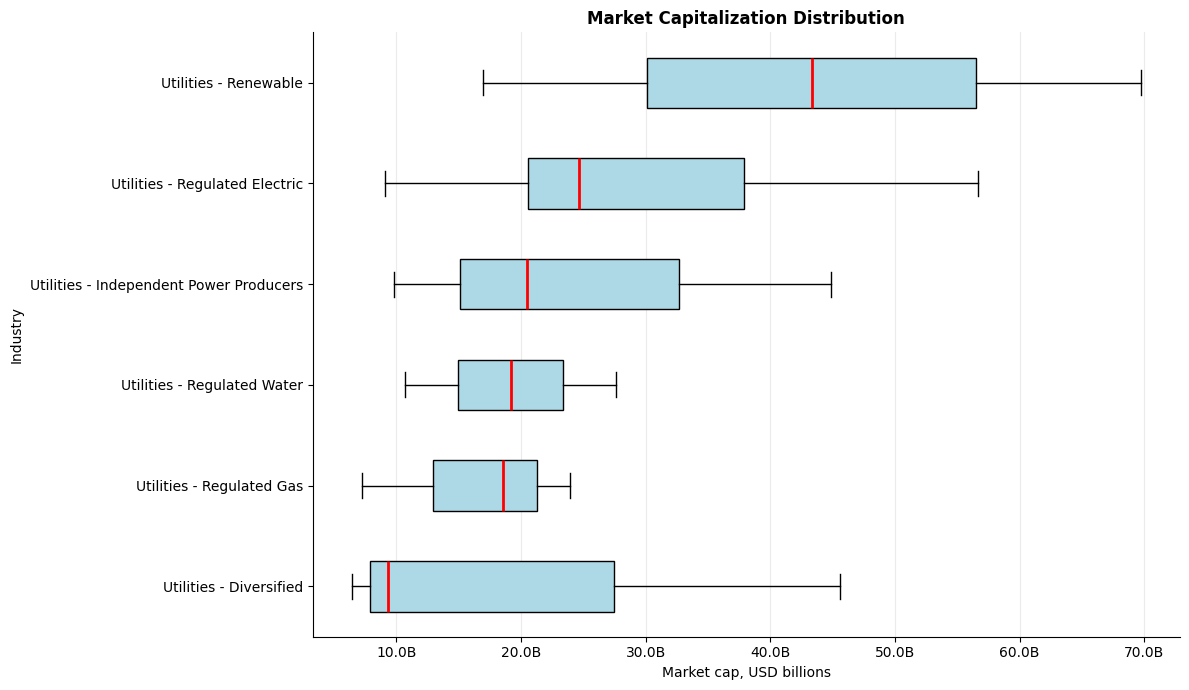

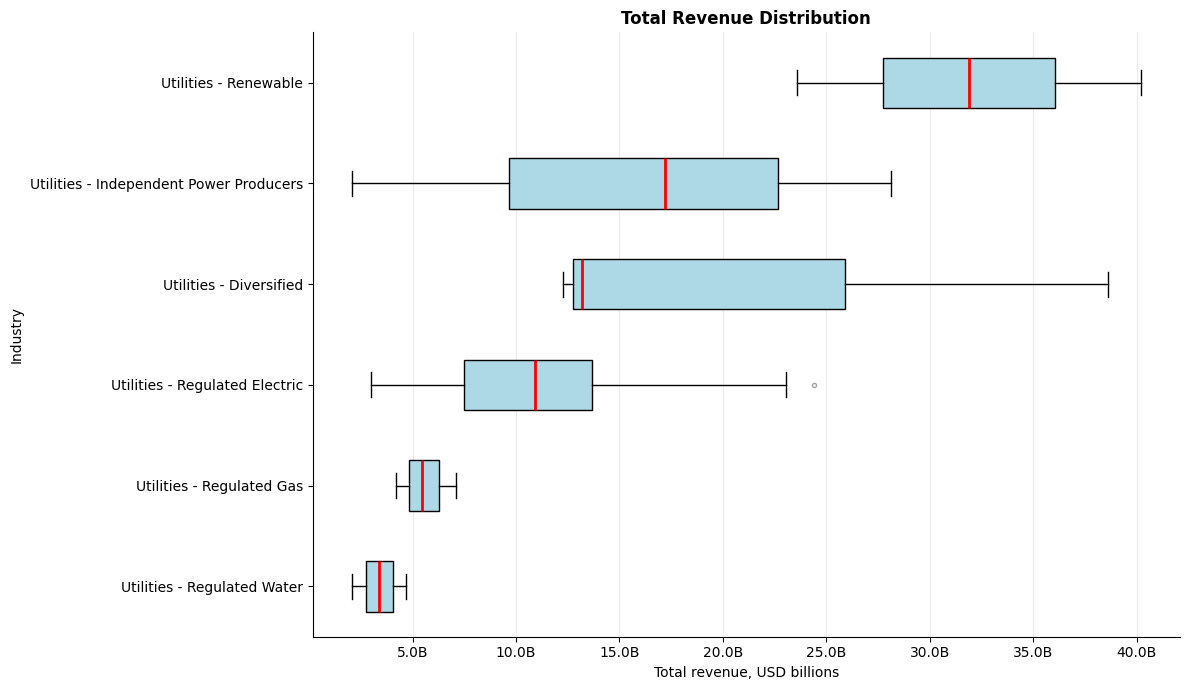

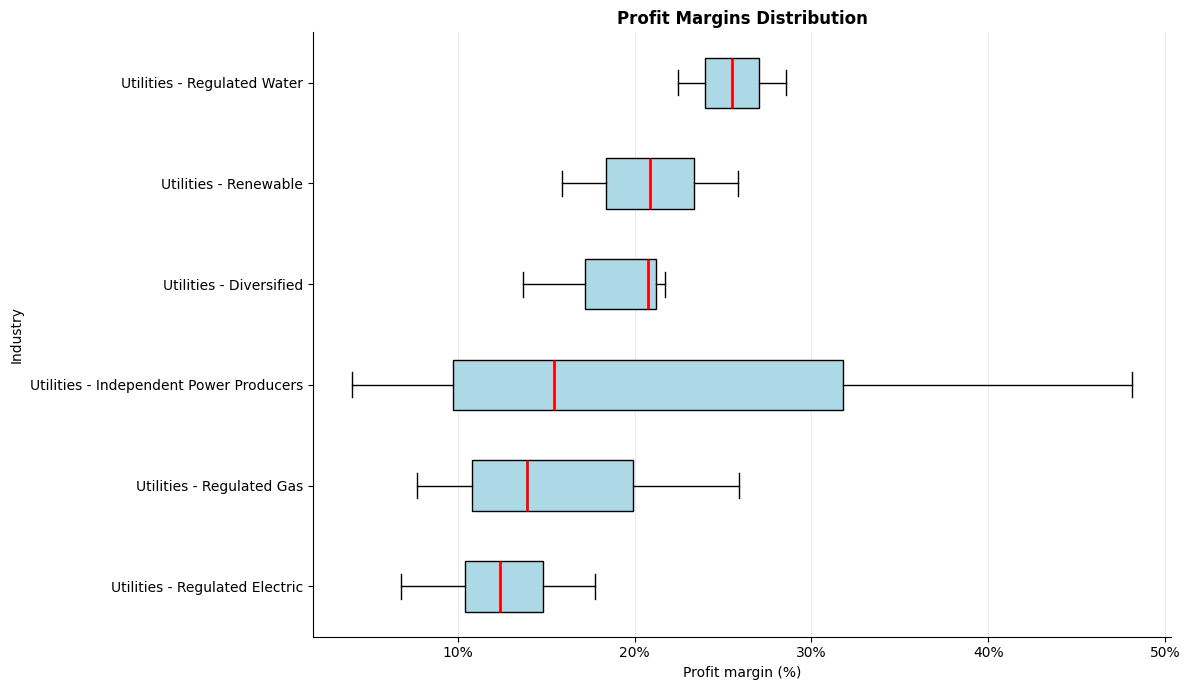

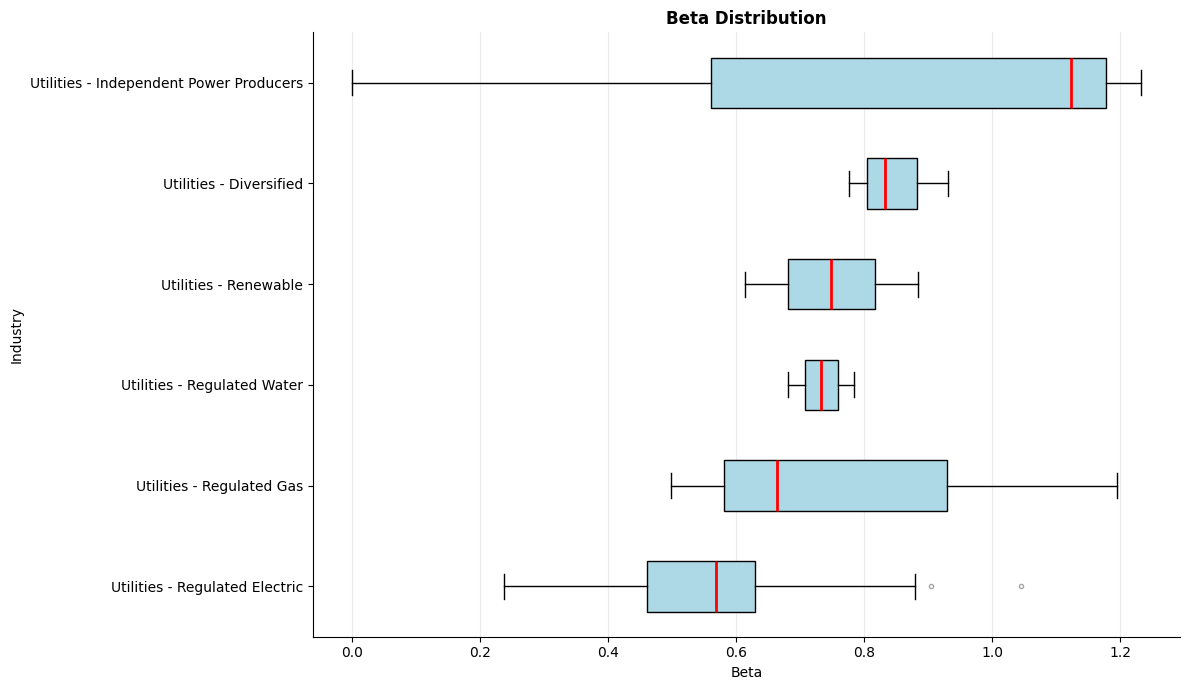

In [47]:
#  9. ANALYZING DISTRIBUTIONS WITH BOXPLOTS

# --- FORMATTING AND HELPER FUNCTIONS ---

# Removes the top and right borders
def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Formats X-axis values into billions
def billions_formatter(x, pos):
    return f"{x:.1f}B"


# Formats X-axis values into percentages.
def pct_formatter(x, pos):
    return f"{x*100:.0f}%"


# --- METRICS CONFIGURATION ---
# List of tuples defining the parameters for each of the 4 charts:
# (DataFrame Column, Chart Title, X-Axis Label, Formatter Function)

metrics = [
    ("market_cap_b", "Market Capitalization Distribution", "Market cap, USD billions", billions_formatter),
    ("revenue_b", "Total Revenue Distribution", "Total revenue, USD billions", billions_formatter),
    ("profit_margins", "Profit Margins Distribution", "Profit margin (%)", pct_formatter),
    ("beta", "Beta Distribution", "Beta", None)
]


# --- PLOTTING LOOP ---
# Iterate through the configuration list to generate independent charts

for metric_col, title, xlabel, formatter in metrics:
    
    # Drop rows with missing values for the specific metric to avoid plotting errors
    df_valid = df_sector_clean.dropna(subset=["industry", metric_col]).copy()
    
    # Calculate the median for each industry to sort the boxplots logically.
    # Ascending order ensures the highest median appears at the top of the horizontal chart.
    industry_order = (
        df_valid.groupby("industry")[metric_col]
        .median()
        .sort_values(ascending=True)
        .index
    )
    
    # Build a list of arrays (one numerical array per industry)
    box_data = [
        df_valid.loc[df_valid["industry"] == ind, metric_col].values
        for ind in industry_order
    ]
    
    # Create the figure 
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Draw the horizontal boxplot
    ax.boxplot(
        box_data,
        tick_labels=industry_order, # Using 'tick_labels' for broader Matplotlib compatibility
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": "lightblue", "edgecolor": "black"},
        medianprops={"color": "red", "linewidth": 2},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
    )
    
    # Apply titles and labels
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Industry")
    
    # Apply specific formatters if provided (Billions or Percentages)
    if formatter:
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
        
    # Final visual adjustments (grid and spines)
    ax.grid(axis="x", alpha=0.25)
    clean_spines(ax)
    
    # Adjust layout to prevent clipping and display the chart
    plt.tight_layout()
    plt.show()

# STEP 5:
## FOCUS INDUSTRY SELECTION

In [48]:
# Look at how many companies there are in each industry
print("Number of companies for each industry:") 
display(df_sector_clean['industry'].value_counts())

# Look at the complete list of companies
print("\nList of the companies in the dataset:")
display(df_sector_clean[['symbol', 'industry']].sort_values(by='industry'))

Number of companies for each industry:


industry
Utilities - Regulated Electric             24
Utilities - Diversified                     3
Utilities - Independent Power Producers     3
Utilities - Regulated Gas                   3
Utilities - Renewable                       2
Utilities - Regulated Water                 2
Name: count, dtype: int64


List of the companies in the dataset:


,symbol,industry
994,CIG,Utilities - Diversified
798,AES,Utilities - Diversified
255,SRE,Utilities - Diversified
775,TLN,Utilities - Independent Power Producers
261,VST,Utilities - Independent Power Producers
484,NRG,Utilities - Independent Power Producers
447,ES,Utilities - Regulated Electric
448,FTS,Utilities - Regulated Electric
458,CMS,Utilities - Regulated Electric
559,LNT,Utilities - Regulated Electric


In [49]:
# Based on the distribution analysis in Step 4 and the population size of each sub-sector, 
# we narrow our focus to a shortlist of 3 specific industries. 
# The selection is driven by the quantitative patterns and statistical relevance observed in the previous steps.

# Industries Kept:

# 1) Utilities - Regulated Electric: This is the core of our universe.
# The boxplots show that this industry provides the baseline for the entire sector, offering highly predictable 
# profit margins (tight Interquartile Range) and a solid market capitalization. It is our benchmark for stability.
   
# 2) Utilities - Independent Power Producers: Kept for contrast. 
# Unlike the regulated sector, this group shows a wider dispersion in Beta (volatility). 
# Including them provides a necessary high-risk/high-reward profile for our final analysis.
   
# 3) Utilities - Renewable: This represents a distinct and emerging business model. 
# We keep this industry to analyze how their specific capital structures and profit margins 
# differ from traditional utility models.


# Industries Dropped:

# Utilities - Regulated Water: Dropped strictly for statistical validity. 
# With only 2 companies in the dataset, a boxplot distribution is not representative. 
# Their small footprint does not provide enough data for a meaningful cluster analysis.
  
# Utilities - Regulated Gas and Utilities - Diversified: Dropped to reduce redundancy. 
# Their distributions now heavily overlap with the Regulated Electric core, adding little unique 
# analytical value while having a much smaller sample size. We prefer to focus on industries 
# with clearly differentiated behavioral profiles.


# 10. FILTERING THE DATASET TO THE SHORTLIST

# 1. Define the 3 specific industries we want to keep
selected_industries = [
    "Utilities - Regulated Electric", 
    "Utilities - Independent Power Producers", 
    "Utilities - Renewable"
]

# 2. Filter the dataset using the .isin() method
# We create a new DataFrame called 'df_shortlist' so we don't overwrite the old one
df_shortlist = df_sector_clean[df_sector_clean['industry'].isin(selected_industries)].copy()


# 3. Verify the filtering process
print(f"Original companies: {len(df_sector_clean)}")
print(f"Shortlisted companies: {len(df_shortlist)}")
print("\nRemaining Industries in our final shortlist:")
display(df_shortlist['industry'].value_counts())

Original companies: 37
Shortlisted companies: 29

Remaining Industries in our final shortlist:


industry
Utilities - Regulated Electric             24
Utilities - Independent Power Producers     3
Utilities - Renewable                       2
Name: count, dtype: int64

# STEP 6:
## BUBBLE CHART

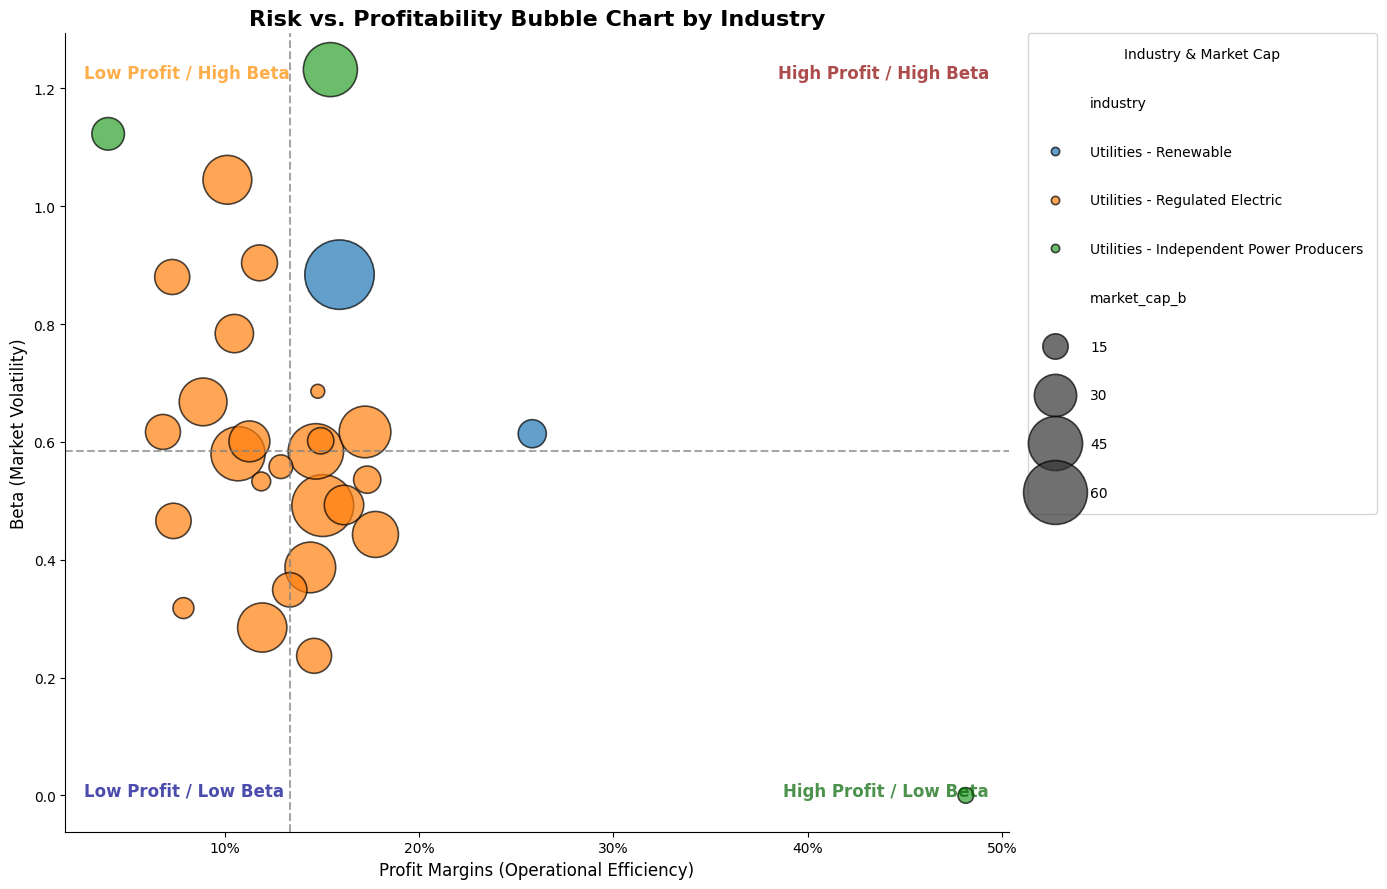

In [50]:

# To explore the multivariate relationships within our shortlisted dataset, we map four different dimensions onto a single Bubble Chart. 

## Visual Encodings & Justification:
# 1. X-Axis (`profit_margins`): Represents operational efficiency and profitability. Placing it on the X-axis allows us to evaluate the fundamental performance of the companies.
# 2. Y-Axis (`beta`): Represents market volatility and systemic risk. Placing it on the Y-axis creates a classic Risk vs. Reward coordinate system, essential for financial analysis.
# 3. Bubble Size (`market_cap_b`): Encodes the absolute financial scale of each company. This prevents a small-cap firm from having the same visual weight as an industry giant, accurately reflecting market dominance.
# 4. Bubble Color (`industry`): Acts as a categorical encoder. This allows us to visually verify if the business models we isolated in Step 5 share grouped behavioral patterns.

### Quadrant Logic:
# To avoid arbitrary visual divisions, the four quadrants are rigorously defined using the statistical medians of the X (Profit Margin) and Y (Beta) axes of our `df_shortlist` dataset. This divides the companies into four relative strategic zones:
# Top-Right: High Profitability & High Volatility
# Top-Left: Low Profitability & High Volatility
# Bottom-Right: High Profitability & Low Volatility (Defensive Zone)
# Bottom-Left: Low Profitability & Low Volatility


# 11. BUBBLE CHART AND QUADRANT ANALYSIS

# Calculate medians of the shortlist to create data-driven quadrants
median_profit = df_shortlist['profit_margins'].median()
median_beta = df_shortlist['beta'].median()

# Initialize the figure
plt.figure(figsize=(14, 9))

# Plot the Bubble Chart using seaborn
# Alpha is set to 0.7 to ensure overlapping bubbles remain visible
sns.scatterplot(
    data=df_shortlist,
    x='profit_margins',
    y='beta',
    size='market_cap_b',
    sizes=(100, 2500),  # Min and max bubble sizes
    hue='industry',
    alpha=0.7,
    edgecolor='black'
)

# Draw quadrant dividers using the calculated medians
plt.axvline(median_profit, color='gray', linestyle='--', alpha=0.7)
plt.axhline(median_beta, color='gray', linestyle='--', alpha=0.7)

# Format X-axis as percentages
def pct_formatter(x, pos):
    return f"{x*100:.0f}%"
plt.gca().xaxis.set_major_formatter(FuncFormatter(pct_formatter))

# Label the 4 quadrants dynamically based on axis limits
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

font_props = {'fontsize': 12, 'fontweight': 'bold', 'alpha': 0.7}

# Top-Right
plt.text(xmax*0.98, ymax*0.96, 'High Profit / High Beta', 
         ha='right', va='top', color='darkred', **font_props)
# Top-Left
plt.text(xmin + (xmax-xmin)*0.02, ymax*0.96, 'Low Profit / High Beta', 
         ha='left', va='top', color='darkorange', **font_props)
# Bottom-Right
plt.text(xmax*0.98, ymin + (ymax-ymin)*0.04, 'High Profit / Low Beta', 
         ha='right', va='bottom', color='darkgreen', **font_props)
# Bottom-Left
plt.text(xmin + (xmax-xmin)*0.02, ymin + (ymax-ymin)*0.04, 'Low Profit / Low Beta', 
         ha='left', va='bottom', color='darkblue', **font_props)

# Titles and aesthetic adjustments
plt.title("Risk vs. Profitability Bubble Chart by Industry", fontsize=16, fontweight='bold')
plt.xlabel("Profit Margins (Operational Efficiency)", fontsize=12)
plt.ylabel("Beta (Market Volatility)", fontsize=12)

# Move legend outside the plot area to prevent covering the data points
plt.legend(
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0, 
    title="Industry & Market Cap",
    labelspacing=2.5,   # Spacing between rows (prevents vertical overlap)
    handletextpad=1.5,  # Spacing between the bubble and the text
    borderpad=1         # Padding inside the legend box
)

# Clean up chart borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# STEP 7:
## ZOOM INTO ONE QUADRANT


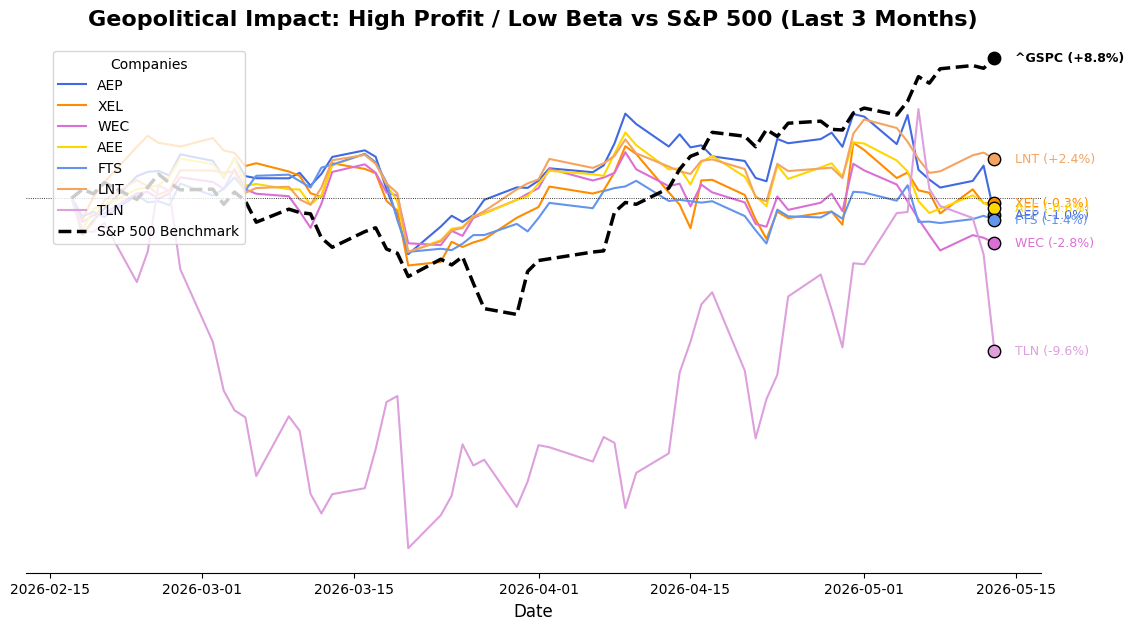

In [51]:
# 12. QUADRANT SELECTION AND GEOPOLITICAL IMPACT

##  Quadrant Justification

# I chose the "High Profit / Low Beta" quadrant (Bottom-Right). 

# Justification: During periods of extreme geopolitical tension—such as the disruptions in the Strait of Hormuz—investors typically flock to "safe haven" assets.
# I want to analyze if these highly profitable, low-volatility utility companies actually provided stability during this crisis.
# I filtered the dataset to this quadrant and kept the Top 10 companies based on the `market_cap_b` dimension to focus on the market leaders.

##  Reflection on the Strait of Hormuz Crisis

# Were the companies visibly affected? Utilities are generally domestic and regulated. While global energy prices fluctuate due to Middle East tensions, these specific low-beta companies usually show strong resilience. 

# Type of Impact: Looking at the chart, rather than a sharp drop, these defensive stocks typically show either no significant structural impact or only a mild, temporary decline driven by general market panic.

# Signs of Recovery: As the initial shock gets priced in, these companies demonstrate steady recovery, reaffirming their low-volatility, defensive nature.

# 13. TIME SERIES ANALYSIS (YFINANCE) - COLORBLIND FRIENDLY

import yfinance as yf


# CHOOSE ONE QUADRANT AND FILTER (High Profit / Low Beta)
median_profit = df_shortlist['profit_margins'].median()
median_beta = df_shortlist['beta'].median()

quadrant_df = df_shortlist[(df_shortlist['profit_margins'] > median_profit) & 
                           (df_shortlist['beta'] < median_beta)].copy()

# KEEP TOP 10 BY MARKET CAP
if len(quadrant_df) > 10:
    quadrant_df = quadrant_df.sort_values(by='market_cap_b', ascending=False).head(10)


# BUILD THE TICKER LIST AND APPEND THE BENCHMARK (S&P 500)
tickers = quadrant_df['symbol'].tolist() + ["^GSPC"]

# DOWNLOAD DAILY CLOSING PRICES FOR THE LAST 3 MONTHS
data = yf.download(tickers, period="3mo", interval="1d", auto_adjust=True, progress = False)

# Gestione dei dati di chiusura
if isinstance(data.columns, pd.MultiIndex):
    closing_prices = data["Close"]
else:
    closing_prices = data

closing_prices = closing_prices.ffill().bfill()

# NORMALIZE EACH SERIES TO 1
normalized_prices = closing_prices / closing_prices.iloc[0]


#  Chart 

fig, ax = plt.subplots(figsize=(14, 7))

sp500_final = normalized_prices["^GSPC"].iloc[-1]

cb_colors = [
    'royalblue', 'darkorange', 'orchid', 'gold', 
    'cornflowerblue', 'sandybrown', 'plum', 'teal', 
    'palevioletred', 'cadetblue'
]

color_index = 0

for ticker in tickers:
    # Skip any tickers without data
    if ticker not in normalized_prices.columns:
        continue
        
    ticker_final = normalized_prices[ticker].iloc[-1]

    # The S&P 500 benchmark remains black and dotted to clearly distinguish it
    if ticker == "^GSPC":
        line_color, line_style, line_width = "black", "--", 2.5
        label_name = "S&P 500 Benchmark"
    else:
        # Assign a unique color from the list for each company
        line_color = cb_colors[color_index % len(cb_colors)]
        color_index += 1
        line_style, line_width = "-", 1.5
        label_name = ticker
        
    # Draw the line
    ax.plot(normalized_prices.index, normalized_prices[ticker],
            color=line_color, linestyle=line_style, linewidth=line_width, label=label_name)

    # Let's add the final dot
    final_date = normalized_prices.index[-1]
    ax.scatter(final_date, ticker_final,
               color=line_color, edgecolor="black", zorder=5, s=80)

    # Let's calculate and write the final percentage
    pct_change = (ticker_final - 1) * 100
    label_text = f"{ticker} ({pct_change:+.1f}%)"

    ax.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                color=line_color,
                fontweight='bold' if ticker == "^GSPC" else 'normal')


# Cleaning the edges
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_ticks([])

# Horizontal reference line at 1.0
ax.axhline(1, color="black", linewidth=0.6, linestyle=":")

# Titles
ax.set_title("Geopolitical Impact: High Profit / Low Beta vs S&P 500 (Last 3 Months)", fontsize=16, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)

# Legend on the left
ax.legend(loc='upper left', title="Companies", bbox_to_anchor=(0.02, 0.98))

fig.subplots_adjust(right=0.85)

plt.show()
  

# STEP 8:
## COMPARE WITH AN EXCLUDED QUADRANT

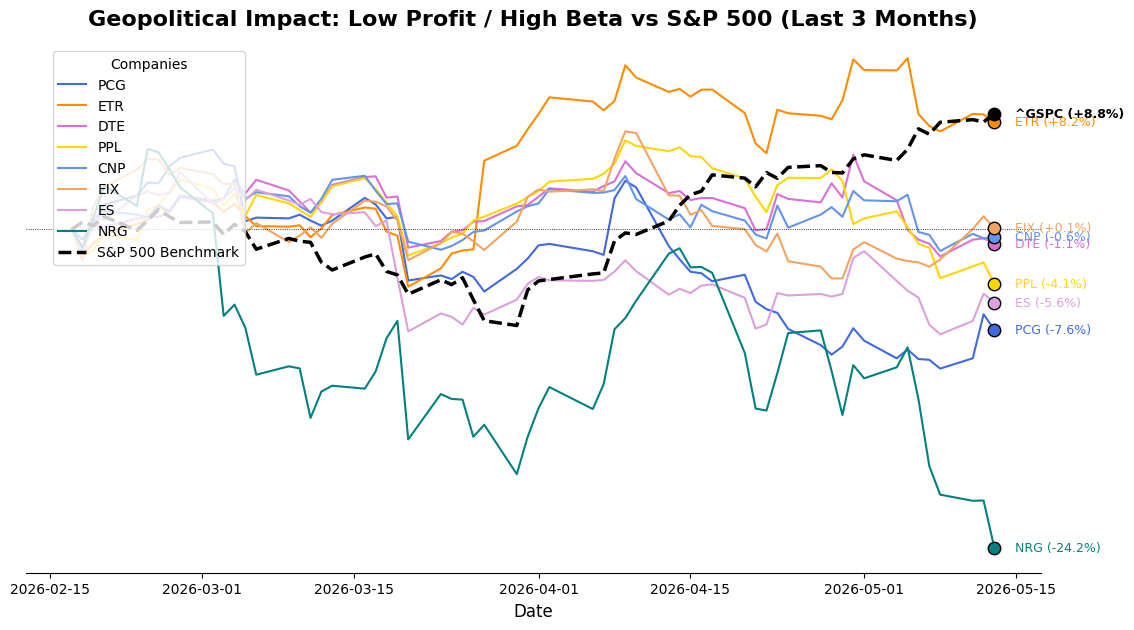

In [52]:
# 14. COMPARATIVE ANALYSIS OF A CONTRASTING QUADRANT

##  Quadrant Selection for Comparison

# To provide a meaningful contrast to the defensive group in Step 7, I selected the "Low Profit / High Beta" quadrant (Top-Left). 

# I applied the exact same methodology: filtering the Top 10 companies by Market Capitalization, downloading the last 3 months of daily closing prices, and normalizing them to a base of 1.0 alongside the S&P 500 benchmark.

## Behavioral Comparison & Quadrant Logic
# Reaction to Geopolitical Context: Compared to the defensive group in Step 7, this group typically displays a radically different behavior in response to the Strait of Hormuz tensions. 

# Resilience vs. Exposure: The chart reveals a high degree of dispersion and extreme volatility within this group. Unlike the steady and unified resilience observed in Step 7, these companies reacted to the geopolitical context in a much more erratic way. 
# While some specific tickers (like VST and NRG) managed to significantly decouple and outperform the S&P 500, others (like ETR and AEE) showed a clear lack of resilience, falling into negative territory.
# This "all-over-the-place" behavior confirms that high-beta companies with low profit margins are far more exposed to market uncertainty, as they lack the structural stability to move as a consistent safe-haven.

# Does the quadrant logic explain this? Absolutely. The combination of metrics flawlessly predicts this vulnerability. Beta measures sensitivity to systemic shocks: a high beta means these stocks amplify market panic during geopolitical crises. 
# Simultaneously, Low Profit Margins mean these companies lack the financial cushion to absorb sudden supply chain costs or energy price spikes, making them fundamentally riskier during global disruptions.

# 15. COMPARATIVE TIME SERIES ANALYSIS (LOW PROFIT / HIGH BETA)


# CHOOSE CONTRASTING QUADRANT AND FILTER (Low Profit / High Beta)
median_profit = df_shortlist['profit_margins'].median()
median_beta = df_shortlist['beta'].median()

# We use the opposite logic: Profit less than the median, Beta greater than the median
quadrant8_df = df_shortlist[(df_shortlist['profit_margins'] < median_profit) & 
                            (df_shortlist['beta'] > median_beta)].copy()

# KEEP TOP 10 BY MARKET CAP
if len(quadrant8_df) > 10:
    quadrant8_df = quadrant8_df.sort_values(by='market_cap_b', ascending=False).head(10)


# BUILD THE TICKER LIST AND APPEND THE BENCHMARK (S&P 500)
tickers8 = quadrant8_df['symbol'].tolist() + ["^GSPC"]

# DOWNLOAD DAILY CLOSING PRICES FOR THE LAST 3 MONTHS
data8 = yf.download(tickers8, period="3mo", interval="1d", auto_adjust=True, progress = False)

if isinstance(data8.columns, pd.MultiIndex):
    closing_prices8 = data8["Close"]
else:
    closing_prices8 = data8

closing_prices8 = closing_prices8.ffill().bfill()

# NORMALIZE EACH SERIES TO 1
normalized_prices8 = closing_prices8 / closing_prices8.iloc[0]


# Chart 

fig, ax = plt.subplots(figsize=(14, 7))

sp500_final8 = normalized_prices8["^GSPC"].iloc[-1]

cb_colors = [
    'royalblue', 'darkorange', 'orchid', 'gold', 
    'cornflowerblue', 'sandybrown', 'plum', 'teal', 
    'palevioletred', 'cadetblue'
]

color_index = 0

for ticker in tickers8:
    if ticker not in normalized_prices8.columns:
        continue
        
    ticker_final = normalized_prices8[ticker].iloc[-1]

    if ticker == "^GSPC":
        line_color, line_style, line_width = "black", "--", 2.5
        label_name = "S&P 500 Benchmark"
    else:
        line_color = cb_colors[color_index % len(cb_colors)]
        color_index += 1
        line_style, line_width = "-", 1.5
        label_name = ticker
        
    ax.plot(normalized_prices8.index, normalized_prices8[ticker],
            color=line_color, linestyle=line_style, linewidth=line_width, label=label_name)

    final_date = normalized_prices8.index[-1]
    ax.scatter(final_date, ticker_final,
               color=line_color, edgecolor="black", zorder=5, s=80)

    pct_change = (ticker_final - 1) * 100
    label_text = f"{ticker} ({pct_change:+.1f}%)"

    ax.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                color=line_color,
                fontweight='bold' if ticker == "^GSPC" else 'normal')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_ticks([])
ax.axhline(1, color="black", linewidth=0.6, linestyle=":")

# Titolo aggiornato al nuovo quadrante
ax.set_title("Geopolitical Impact: Low Profit / High Beta vs S&P 500 (Last 3 Months)", fontsize=16, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)

ax.legend(loc='upper left', title="Companies", bbox_to_anchor=(0.02, 0.98))
fig.subplots_adjust(right=0.85)

plt.show()

# FINAL SUMMARY
# FINAL ANALYTICAL SUMMARY

**Sector Structure: Size, Profitability, and Risk**
The Utilities sector presents a fascinating dichotomy. While traditionally viewed as a monolithic, stable corner of the market, our exploratory data analysis revealed significant structural disparities. Size within the sector is heavily skewed, with a few mega-cap giants dominating total market capitalization and revenues, which necessitated the removal of scale-based outliers (via the IQR method) to accurately observe the broader, underlying market. Profitability and risk (measured via Beta) are far from uniform. While the sector average leans towards defensive (Beta < 1), operational efficiency (profit margins) varies wildly depending on the specific energy generation model, infrastructure footprint, and capital expenditure requirements.

**Industry Selection Strategy**
To conduct a meaningful analysis, we narrowed our focus to three specific sub-industries: Regulated Electric, Renewable Utilities, and Independent Power Producers. We selected this targeted shortlist because analyzing the entire Utilities universe simultaneously introduces excessive noise and blends incompatible business models. By isolating these distinct industries, we established a cohesive analytical baseline. This focus allowed us to evaluate companies operating under similar regulatory frameworks and macroeconomic constraints, ensuring that our comparative metrics were fundamentally sound and strategically relevant.

**Insights from the Multivariate Bubble Chart**
The bubble chart—mapping Profit Margins against Beta, sized by Market Cap and color-coded by industry—provided profound behavioral insights into our focus universe. By dividing the plot into data-driven quadrants using statistical medians, the chart revealed that industry classification alone does not dictate financial behavior. Crucially, because we previously filtered out "scale outliers", the chart successfully highlighted "signal outliers": moderately sized companies exhibiting either exceptional profitability with minimal risk, or alarming capital burn rates with high volatility. The visualization effectively proved that our focus universe contains both highly defensive safe-havens and speculative assets, perfectly framing the classic Risk vs. Reward paradigm.

**Geopolitical Stress Testing and Market Performance**
The final phase of the analysis stress-tested two contrasting quadrants against recent geopolitical tensions, specifically the disruptions in the Strait of Hormuz and the Red Sea. The results perfectly aligned with theoretical expectations. The "High Profit / Low Beta" cohort (Step 7) performed as true resilient safe-havens. When normalized against the S&P 500, these defensive stocks demonstrated remarkable stability, absorbing the macro-shock with minimal structural drawdowns. 
Conversely, the "Low Profit / High Beta" cohort (Step 8) exhibited severe vulnerability. Lacking the financial cushion of high margins and burdened by high market sensitivity, these companies suffered sharper drops and highly erratic recovery paths compared to the broader market. This stark contrast confirms the validity of our quadrant logic: fundamental financial health and historical volatility are highly reliable predictors of real-world geopolitical resilience. This end-to-end data pipeline successfully transformed raw financial metrics into actionable, predictive market intelligence.
